In [1]:
"""
Testing the fb_tools functions
"""

# standard imports
import os
import geopandas as gpd
import pandas as pd

from pathlib import Path
from os.path import join

# Import fb_tools (!!)
from fb_tools import lfps_request, run_flammap_scenarios, list_files

# directories
# use the current working directory
projdir = Path.cwd().parents[1] # moves up two, outside code directory
print(f"Project directory set to: {projdir}")

# environ vars
proj_crs = 26913  # NAD83 UTM Zone 13N

print("Ready to go !")

Project directory set to: /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper
Ready to go !


<Axes: >

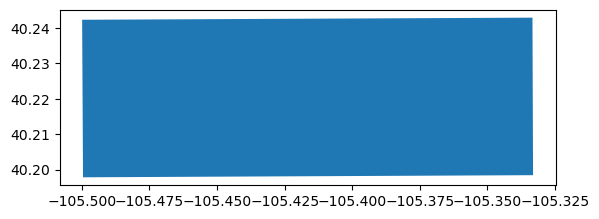

In [2]:
# --- Load a test AOI
fp = os.path.join(projdir, 'data/spatial/raw/test_aois.gpkg')
aoi = gpd.read_file(fp, layer='button_rock')
aoi.plot()

## lfps_request module

/Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/data/spatial/mod/testing/test_lcp.tif


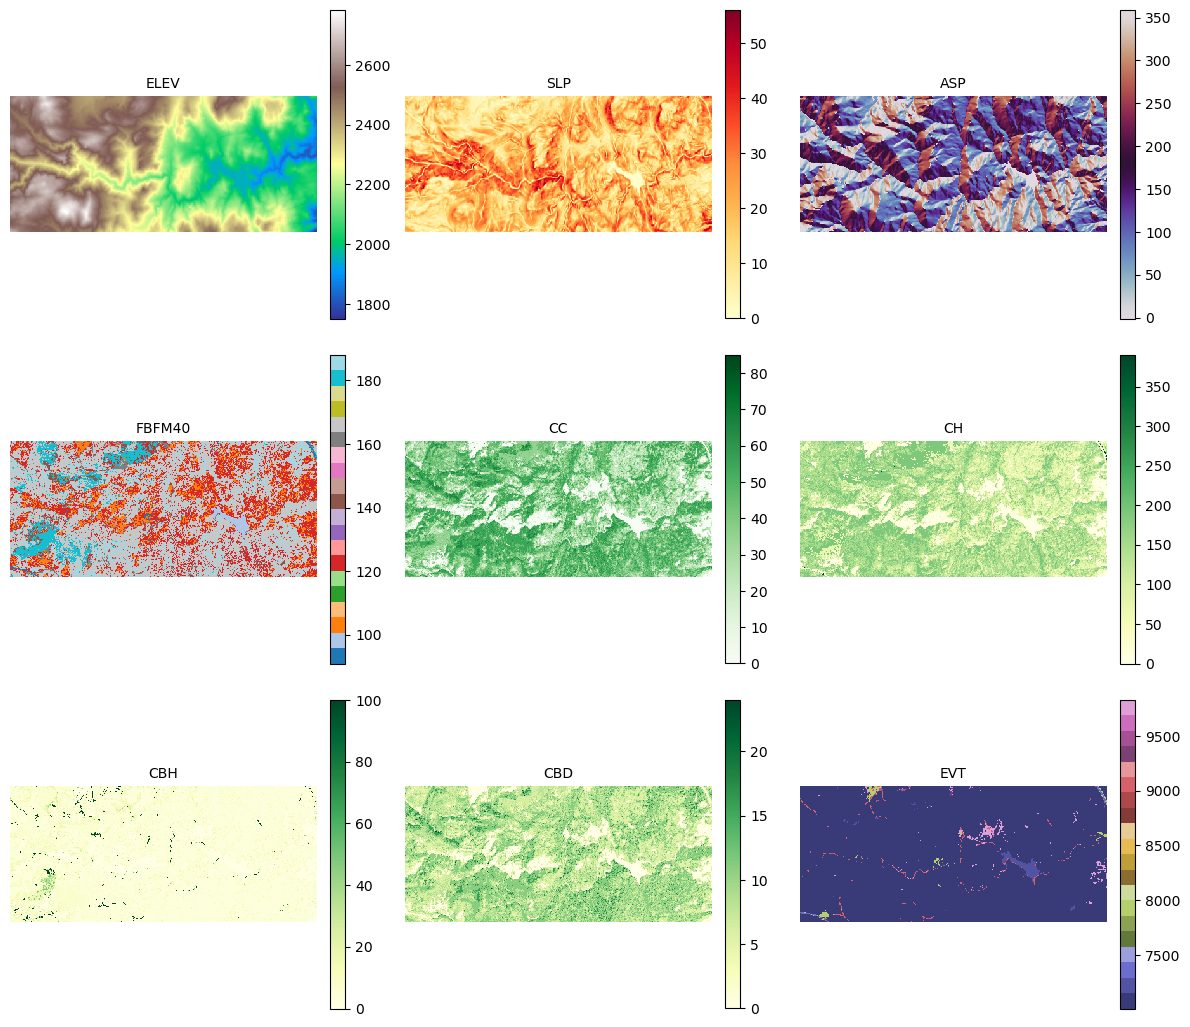

In [3]:
# --- Run a request to LFPS
out_fp = os.path.join(projdir, 'data/spatial/mod/testing')
rename='test_lcp'
runit=False # set to True to re-run
if not os.path.exists(join(out_fp, f"{rename}.tif")) or runit is True:
    lcp_da = lfps_request(
        region=aoi,
        out_dir=os.path.join(projdir, 'data/spatial/mod/testing'),
        lf_version='200', # 2020 capable
        lodgepole_adjust=True,
        rename='test_lcp'
    )
else:
    lcp_da = join(out_fp,f'{rename}.tif')
print(lcp_da)

from fb_tools import plot_bands

fig, axes = plot_bands(lcp_da)

## apply_treatment module

In [4]:
# --- Run fuel modifications for low, moderate, and high-severity wildfire

from fb_tools import apply_treatment

# load the canopy and surface modifications tables
canopy  = pd.read_csv(projdir / "data/tabular/raw/fuel_mods/canopy_effects.csv")
surface = pd.read_csv(projdir / "data/tabular/raw/fuel_mods/surface_effects.csv")
print(f"Treatments: {canopy.Treatment.unique()}")

# --- Landscape-scale (treat every pixel)
treated = apply_treatment(
    lcp = lcp_da,
    canopy_df = canopy,
    surface_df = surface,
    scenario = {"canopy": "ModSevWF", "surface": "Manage"},
)

# --- Save this file out
out_fp = os.path.join(projdir, 'data/spatial/mod/testing/treated/ModSevWF.tif')
os.makedirs(os.path.dirname(out_fp), exist_ok=True)
treated.rio.to_raster(out_fp)

Treatments: ['Thin' 'Hand Thin' 'Mech Thin' 'RxFire' 'Complete Hand' 'Complete Mech'
 'Masticate' 'Patch' 'LowSevWF' 'ModSevWF' 'HighSevWF' 'Overstory']


## fetch_osm_roads module

Querying OSM for road and trail features...
OSM: 59 road segments, 124 trail segments


<Axes: >

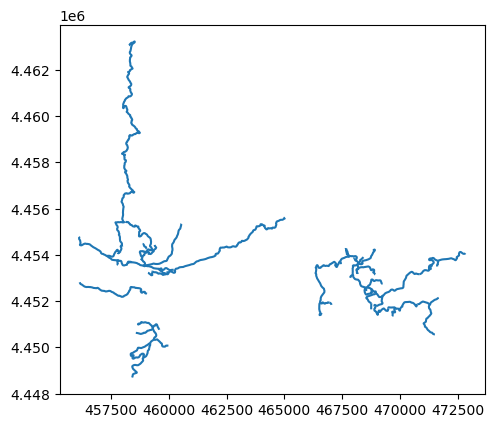

In [8]:
from fb_tools import fetch_osm_roads

roads, trails = fetch_osm_roads(aoi, out_crs=26913)
roads.plot()

## calculate_sdi module

In [9]:
from fb_tools import calculate_sdi, calculate_delta_sdi

sdi_base = calculate_sdi(
    lcp=lcp_da,
    flame_length=fl_da,
    heat_area=hua_da,
    roads_gdf=roads,
    trails_gdf=trails,
    rtc_path=os.path.join(projdir,'code/dev/SDI/08_RTC_lookup_SDIwt_westernUS_2021_update.txt')
)

TypeError: calculate_sdi() missing 6 required positional arguments: 'lcp', 'flame_length', 'heat_area', 'roads_gdf', 'trails_gdf', and 'rtc_path'

## build_scenarios module(s)

In [ ]:
from fb_tools import build_scenarios, run_batch, list_files, plot_bands

# --- Paths
projdir     = Path.cwd().parents[1]
fm_exe      = list_files(projdir, "TestFlamMap.exe", recursive=True)[0]
lcp_dir     = projdir / "data/spatial/fuelscape"
output_root = projdir / "data/spatial/flammap/outputs"

# --- 1. Define weather / fuel-moisture conditions (one row per scenario)
conditions = pd.DataFrame({
    "Scenario":       ["Pct25", "Pct50", "Pct75", "Pct90", "Pct97"],
    "WIND_SPEED":     [8,       9,       10.5,    12.5,    17   ],
    "WIND_DIRECTION": [-1,      -1,      -1,      -1,      -1   ],
    "FM_1hr":         [21,      12,      9,       7.5,     5.8  ],
    "FM_10hr":        [17,      13,      11,      9.5,     7.5  ],
    "FM_100hr":       [15,      13,      12,      10.5,    8.5  ],
    "FM_herb":        [100,     80,      70,      50,      30   ],
    "FM_woody":       [130,     110,     90,      80,      60   ],
})

# --- 2. LCP files to pair with every condition (baseline + treatments)
lcps = list_files(lcp_dir / "landscape", "*.tif", recursive=False)

# --- 3. Build the cross-product table  (5 conditions × N lcps)
scenarios_df = build_scenarios(
    conditions, lcps,
    outputs="FLAMELENGTH, CROWNSTATE, SPREADRATE",
)
print(f"{len(scenarios_df)} total runs")
scenarios_df[["Scenario", "LCP"]].head(10)

In [ ]:
# --- Option B: load from table
from fb_tools import load_scenarios

scenarios_df = load_scenarios(
    projdir / "data/spatial/flammap/fire_scenarios.csv",
    lcp_dir=lcp_dir / "landscape",   # resolves bare filenames to full paths
)

# filter to scenarios you want before passing to run_batch
scenarios_df = scenarios_df[~scenarios_df["Scenario"].isin(["Pct75", "Pct100"])]
print(f"{len(scenarios_df)} runs after filtering")

## run_batch module

In [ ]:
from fb_tools import run_batch, plot_bands
import rioxarray as rxr

# --- Run (works with df from either A or B above)
summary = run_batch(
    fm_exe=fm_exe,
    scenarios_df=scenarios_df,
    output_root=output_root,
    n_process=6,
    stack_out=True,    # stacks per-output TIFFs → one multiband file per run
    cleanup=True,      # removes the single-band TIFFs afterward
)

# --- Check for any failures
failures = summary[summary["status"] != "success"]
if not failures.empty:
    print("Failed runs:")
    print(failures[["Scenario", "LCP", "status"]])

# --- Inspect one result
row = summary.iloc[0]
stacked_tif = list(Path(row["output_dir"]).glob("*.tif"))[0]
da = rxr.open_rasterio(stacked_tif, masked=True)
fig, axes = plot_bands(da, cols=3)
fig.suptitle(f"{Path(row['LCP']).stem} / {row['Scenario']}", y=1.02)

## suppression module